<a href="https://colab.research.google.com/github/fadiaputriananda/Indonesia-Seismic-Waveform-Analysis/blob/main/01_real_earthquake_waveform_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library ObsPy**

In [ ]:
!pip install obspy

**Install Basic Library**

In [ ]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt

**Connect to Data Seismic (For Example)**

In [ ]:
client = Client("IRIS")

starttime = UTCDateTime("2023-01-01T00:00:00")
endtime = UTCDateTime("2023-01-01T00:15:00")

st = client.get_waveforms(
    network="IU",
    station="ANMO",
    location="00",
    channel="BHZ",
    starttime=starttime,
    endtime=endtime
)

print(st)

1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2023-01-01T00:00:00.019538Z - 2023-01-01T00:14:59.994538Z | 40.0 Hz, 36000 samples


**Plot Waveform**

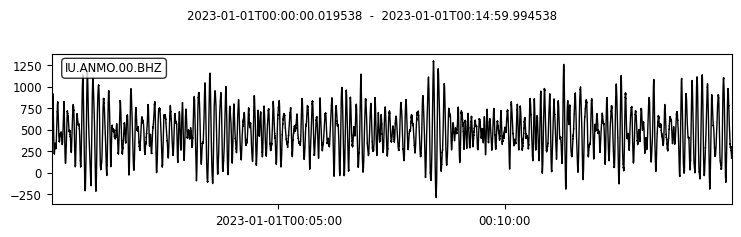

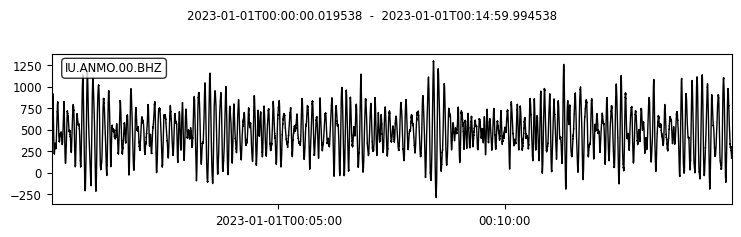

In [ ]:
st.plot()

**Basic Signal Processing**

In [ ]:
st_filtered = st.copy()

In [ ]:
#Apply filter
st_filtered.filter(
    "bandpass",
    freqmin=1,
    freqmax=10
)

1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2023-01-01T00:00:00.019538Z - 2023-01-01T00:14:59.994538Z | 40.0 Hz, 36000 samples

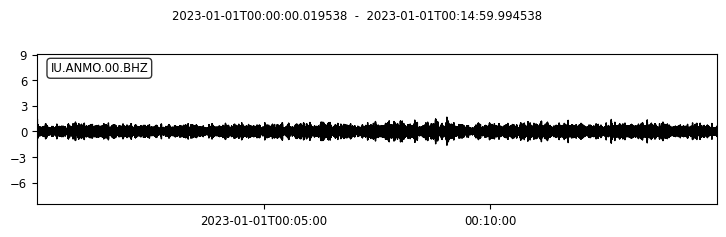

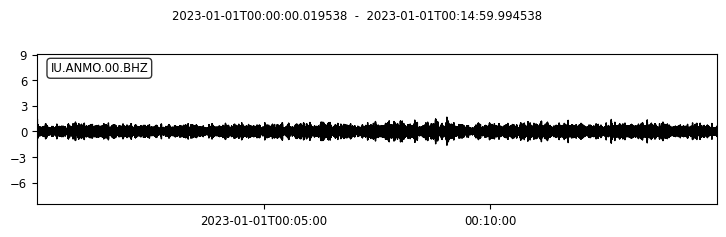

In [ ]:
st_filtered.plot()

The bandpass filter reduces unwanted low and high-frequency noise, making the seismic waveform appear cleaner and easier to observe.

**Connect to Data Earthquake from Event Catalog**

In [ ]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

client = Client("IRIS")

starttime = UTCDateTime("2023-11-01")
endtime = UTCDateTime("2023-11-03")

catalog = client.get_events(
    starttime=starttime,
    endtime=endtime,
    minmagnitude=6,
    latitude=-2,
    longitude=120,
    maxradius=20
)

print(catalog)

/usr/local/lib/python3.12/dist-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


1 Event(s) in Catalog:
2023-11-01T21:04:46.905000Z | -10.034, +123.759 | 6.1  mww


In [ ]:
event = catalog[0]
print(event)

Event:	2023-11-01T21:04:46.905000Z | -10.034, +123.759 | 6.1  mww

	            resource_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?eventid=11763096")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?originid=49166887")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?magnitudeid=214115105")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements


In [ ]:
origin = event.origins[0]

print("Time:", origin.time)
print("Latitude:", origin.latitude)
print("Longitude:", origin.longitude)
print("Depth (km):", origin.depth / 1000)

Time: 2023-11-01T21:04:46.905000Z
Latitude: -10.034
Longitude: 123.7591
Depth (km): 40.0


**Download Waveform**

In [ ]:
#Choose Event Time
event_time = origin.time

print(event_time)

2023-11-01T21:04:46.905000Z


In [ ]:
#Choose Window Event
start_wave = event_time - 300
end_wave = event_time + 1800

In [ ]:
st_indo = client.get_waveforms(
    network="II",
    station="COCO",
    location="00",
    channel="BHZ",
    starttime=start_wave,
    endtime=end_wave
)

print(st_indo)

1 Trace(s) in Stream:
II.COCO.00.BHZ | 2023-11-01T20:59:46.919538Z - 2023-11-01T21:34:46.894538Z | 40.0 Hz, 84000 samples


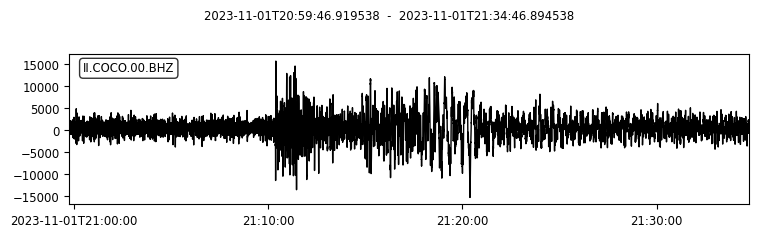

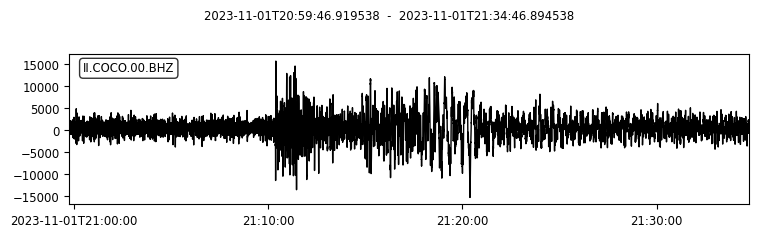

In [ ]:
st_indo.plot()

In [ ]:
#Filtering Event
st_indo_filtered = st_indo.copy()

st_indo_filtered.filter(
    "bandpass",
    freqmin=0.5,
    freqmax=1
)

1 Trace(s) in Stream:
II.COCO.00.BHZ | 2023-11-01T20:59:46.919538Z - 2023-11-01T21:34:46.894538Z | 40.0 Hz, 84000 samples

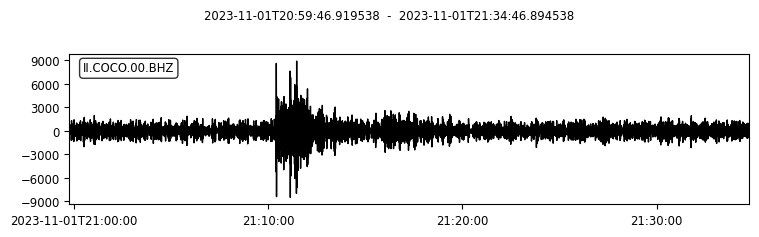

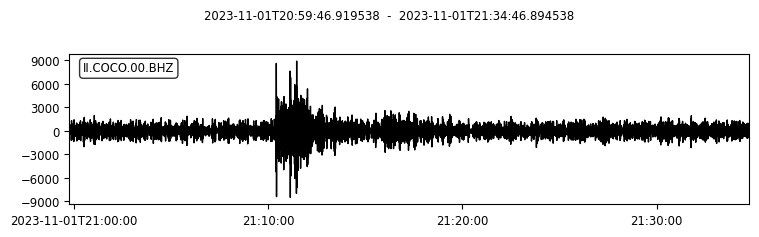

In [ ]:
st_indo_filtered.plot()

The filtered waveform shows clearer seismic signals compared to the raw waveform. Applying a bandpass filter helps reduce noise and improves the visibility of the earthquake signal.

**Event Visualization**

In [ ]:
#Save the event metadata
magnitude = event.magnitudes[0].mag
event_time = origin.time
latitude = origin.latitude
longitude = origin.longitude
depth = origin.depth / 1000

In [ ]:
#Choose the data trace
trace = st_indo_filtered[0]

data = trace.data
times = trace.times()

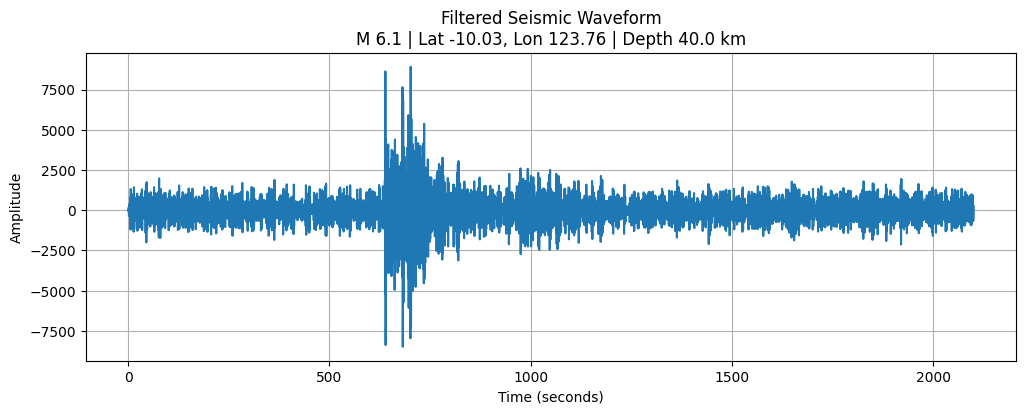

In [ ]:
#Plot Custom Waveform

plt.figure(figsize=(12, 4))

plt.plot(times, data)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    f"Filtered Seismic Waveform\n"
    f"M {magnitude} | Lat {latitude:.2f}, Lon {longitude:.2f} | Depth {depth:.1f} km"
)

plt.grid()

plt.show()

This visualization shows a filtered seismic waveform from a real earthquake event obtained through the IRIS data service. The signal becomes clearer after applying a bandpass filter, allowing better observation of waveform characteristics and amplitude variations associated with the earthquake event.